# 🫀 Machine Learning Models — Classical Baseline Enhancements vs. Deep Learning
## ECG Arrhythmia Detection · MIT-BIH Arrhythmia Database

---

In this notebook, we extend our initial classical machine learning baseline by introducing two major pipelines:

1. **Enhanced Classical Model Suite**: Evaluating Logistic Regression, Random Forest, LightGBM, and Support Vector Machine (RBF kernel) with patient-normalized features and hyperparameter optimization via `RandomizedSearchCV` with `GroupKFold`.
2. **Deep Learning Branch**: Training 1D-CNN, CNN-BiLSTM, and CNN-BiLSTM with Attention models directly on raw $216$-sample beat waveforms ($360\text{ Hz}$, $-0.2\text{ s}$ to $+0.4\text{ s}$ around R-peaks).

All models are evaluated on identical held-out test patients to ensure fair, leakage-free benchmarking.

## 0. Environment Setup

We load essential packages including PyTorch for deep learning architectures and `scipy.stats` for statistical significance testing.

In [26]:
# Uncomment on first run if any of these are missing:
# !pip install torch statsmodels --quiet
import os

# ── macOS fix: must run BEFORE numpy/torch/lightgbm are imported ─────────
# PyTorch bundles its own OpenMP runtime, and LightGBM links a separate one
# (Homebrew's libomp). When both load into the same process, they can crash
# with a segfault instead of erroring cleanly. This tells OpenMP to allow
# both copies to coexist. If you still see a segfault after this, try
# `brew reinstall libomp` in a terminal.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
# Prevent inner OpenMP thread pools (RF/XGBoost/LightGBM) from oversubscribing CPU cores
# while RandomizedSearchCV's outer joblib workers are also running in parallel — this
# combination is what caused the SIGSEGV TerminatedWorkerError.
os.environ.setdefault('OMP_NUM_THREADS', '1')
import time
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis as sp_kurtosis

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 5)})

FS: int = 360
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('mps') if torch.backends.mps.is_available() else (
    torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
)
print(f'PyTorch device: {DEVICE}')

_KAGGLE = '/kaggle/input/mit-bih-arrhythmia-database-modern-2023/'
_LOCAL = os.path.join(os.getcwd(), 'data')

if os.path.isdir(_KAGGLE):
    DATA_DIR = _KAGGLE
    print('Kaggle environment detected.')
elif os.path.isdir(_LOCAL) and any(f.endswith('_ekg.csv') for f in os.listdir(_LOCAL)):
    DATA_DIR = _LOCAL
    print(f'Local data directory: {DATA_DIR}')
else:
    raise FileNotFoundError('Dataset not found — see README for setup instructions.')

print(f'✅ Ready  |  FS = {FS} Hz  |  DATA_DIR = {DATA_DIR}')

PyTorch device: mps
Local data directory: /Users/faridahesham/AI for healthcare workshop/ECG-Arrhythmia-detection/ECG_Arrhythmia_Detection/data
✅ Ready  |  FS = 360 Hz  |  DATA_DIR = /Users/faridahesham/AI for healthcare workshop/ECG-Arrhythmia-detection/ECG_Arrhythmia_Detection/data


---

## Step 1 — Feature Generation and Raw Waveform Extraction

We extract both tabular time-domain features (`mean_amplitude`, `std_amplitude`, `max_amplitude`, `min_amplitude`, `peak_to_peak`, `rr_interval`) and raw $216$-sample beat waveforms for every annotated beat across the dataset.

In [27]:
def load_ekg(record_id: int, data_dir: str = DATA_DIR) -> pd.DataFrame:
    path = os.path.join(data_dir, f'{record_id}_ekg.csv')
    df = pd.read_csv(path)
    if 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'sample_idx'})
    return df


def load_annotations(record_id: int, data_dir: str = DATA_DIR) -> pd.DataFrame:
    ann_files = sorted([
        f for f in os.listdir(data_dir)
        if f.startswith(f'{record_id}_annotations_') and f.endswith('.csv')
    ])
    if not ann_files:
        raise FileNotFoundError(f'No annotation files for record {record_id}')
    frames = [pd.read_csv(os.path.join(data_dir, f)) for f in ann_files]
    df = pd.concat(frames, ignore_index=True)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    if 'index' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'index'})
    if 'annotation_symbol' not in df.columns:
        sym = [c for c in df.columns if 'symbol' in c or 'type' in c]
        df = df.rename(columns={sym[0]: 'annotation_symbol'})
    beat_mask = df['annotation_symbol'].astype(str).str.match(r'^[A-Za-z!/]$', na=False)
    df = df[beat_mask].drop_duplicates(subset='index', keep='first')
    return df.sort_values('index').reset_index(drop=True)[['index', 'annotation_symbol']]


def bandpass_filter(signal, lowcut=0.5, highcut=45.0, fs=FS, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)


def get_record_ids(data_dir: str = DATA_DIR) -> List[int]:
    ids = set()
    for f in os.listdir(data_dir):
        if f.endswith('_ekg.csv'):
            try: ids.add(int(f.replace('_ekg.csv', '')))
            except ValueError: pass
    return sorted(ids)


def extract_beat_window(signal, r_peak, pre_sec=0.2, post_sec=0.4):
    s = r_peak - int(pre_sec * FS)
    e = r_peak + int(post_sec * FS)
    if s < 0 or e > len(signal):
        return None
    return signal[s:e]


def compute_features(beat: np.ndarray, rr: float) -> Dict[str, float]:
    n = len(beat)
    qs, qe = int(0.33 * n), int(0.67 * n)   # centre 1/3 ≈ QRS region
    qrs = beat[qs:qe]
    return {
        # ── original amplitude features ────────────────────────────────
        'mean_amplitude':      float(np.mean(beat)),
        'std_amplitude':       float(np.std(beat)),
        'max_amplitude':       float(np.max(beat)),
        'min_amplitude':       float(np.min(beat)),
        'peak_to_peak':        float(np.ptp(beat)),
        'rr_interval':         float(rr),
        # ── new morphology features (scale-/shift-invariant) ───────────
        'beat_skewness':       float(skew(beat)),             # asymmetry (V-beats lean right)
        'beat_kurtosis':       float(sp_kurtosis(beat)),      # peakedness (BBB = flat)
        'zero_crossing_rate':  float(np.mean(np.diff(np.sign(beat - np.mean(beat))) != 0)),
        # ── new energy features (patient-normalised downstream) ────────
        'qrs_energy':          float(np.mean(qrs ** 2)),      # RMS² in QRS window
        'beat_energy':         float(np.mean(beat ** 2)),     # total beat RMS²
    }


print('✅ Loaders defined.')

✅ Loaders defined.


In [28]:
def build_beat_data_for_record(signal: np.ndarray, ann_df: pd.DataFrame) -> Tuple[pd.DataFrame, np.ndarray]:
    """Extract beats -> tabular features + raw waveform, kept perfectly aligned."""
    indices = ann_df['index'].values
    symbols = ann_df['annotation_symbol'].values
    rows, waveforms = [], []

    for i, (r_idx, sym) in enumerate(zip(indices, symbols)):
        beat = extract_beat_window(signal, int(r_idx))
        if beat is None:
            continue
        rr = (indices[i] - indices[i - 1]) / FS if i > 0 else np.nan
        feats = compute_features(beat, rr)
        feats['symbol'] = sym
        rows.append(feats)
        waveforms.append(beat)

    df = pd.DataFrame(rows)
    valid = df['rr_interval'].notna().values
    df = df[valid].reset_index(drop=True)
    df['label'] = (df['symbol'] != 'N').astype(int)
    waveforms = np.array(waveforms)[valid]
    return df, waveforms


def process_all_records(data_dir: str = DATA_DIR) -> Tuple[pd.DataFrame, np.ndarray]:
    record_ids = get_record_ids(data_dir)
    print(f'Processing {len(record_ids)} records …')
    dfs, wave_list = [], []
    for rid in record_ids:
        try:
            ekg = load_ekg(rid, data_dir)
            ann = load_annotations(rid, data_dir)
            sig = bandpass_filter(ekg['MLII'].values)
            df, waves = build_beat_data_for_record(sig, ann)
            df['record_id'] = rid
            dfs.append(df)
            wave_list.append(waves)
        except Exception as exc:
            print(f'  ⚠️  Record {rid} skipped — {exc}')
    combined = pd.concat(dfs, ignore_index=True)
    raw_waveforms = np.concatenate(wave_list, axis=0)
    print('=' * 65)
    print(f'✅ Combined: {len(combined):,} beats  |  {combined.record_id.nunique()} patients')
    print(f'   Normal (0)   : {(combined.label==0).sum():,}')
    print(f'   Abnormal (1) : {(combined.label==1).sum():,}')
    print('=' * 65)
    return combined, raw_waveforms


features_df, raw_waveforms = process_all_records()
assert len(features_df) == len(raw_waveforms), 'Tabular rows and waveforms must stay aligned!'

# Optional sanity check against the previously saved features.csv, if present
csv_path = os.path.join('data', 'features.csv')
if os.path.exists(csv_path):
    old_df = pd.read_csv(csv_path)
    print(f'\nSanity check vs. data/features.csv: '
          f'{len(old_df):,} rows saved previously, {len(features_df):,} rows regenerated here.')

Processing 48 records …
  ⚠️  Record 102 skipped — 'MLII'
  ⚠️  Record 104 skipped — 'MLII'
✅ Combined: 107,098 beats  |  46 patients
   Normal (0)   : 76,127
   Abnormal (1) : 30,971

Sanity check vs. data/features.csv: 107,098 rows saved previously, 107,098 rows regenerated here.


---

## Step 1.5 — Diagnostic: Signal Amplitude Variance Analysis

We investigate whether raw signal amplitude statistics are dominated by patient identity (due to variations in ADC gain and lead placement across MIT-BIH records) rather than genuine arrhythmia morphology. We compute a variance decomposition (between-record vs. within-record variance) for each amplitude feature.

Feature           Between-record var   Within-record var   Ratio (btwn/within)
mean_amplitude                0.0009              0.0014                  0.61
std_amplitude                 0.0230              0.0097                  2.37
max_amplitude                 0.3130              0.0800                  3.91
min_amplitude                 0.1598              0.0696                  2.30
peak_to_peak                  0.5913              0.1309                  4.52


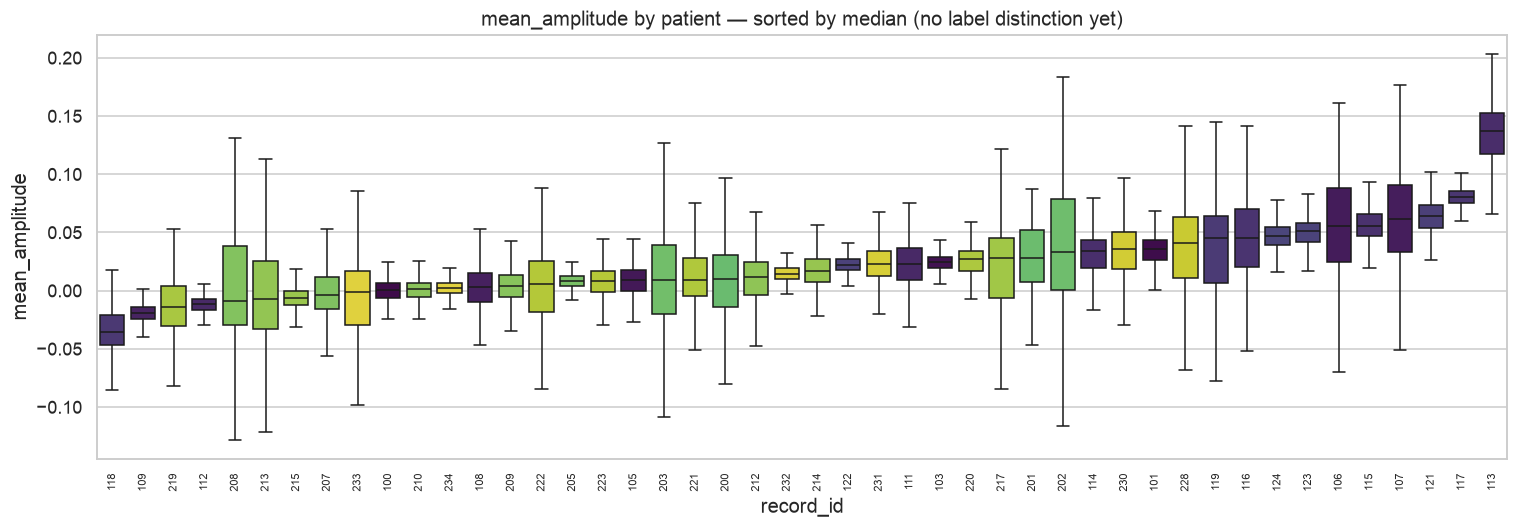

In [29]:
amp_cols_check = ['mean_amplitude', 'std_amplitude', 'max_amplitude', 'min_amplitude', 'peak_to_peak']

print(f"{'Feature':<16}{'Between-record var':>20}{'Within-record var':>20}{'Ratio (btwn/within)':>22}")
for col in amp_cols_check:
    between_var = features_df.groupby('record_id')[col].mean().var()
    within_var = features_df.groupby('record_id')[col].var().mean()
    ratio = between_var / within_var if within_var > 0 else float('inf')
    print(f'{col:<16}{between_var:>20.4f}{within_var:>20.4f}{ratio:>22.2f}')

fig, ax = plt.subplots(figsize=(14, 5))
order = features_df.groupby('record_id')['mean_amplitude'].median().sort_values().index
sns.boxplot(data=features_df, x='record_id', y='mean_amplitude', order=order, ax=ax,
            showfliers=False, hue='record_id', palette='viridis', legend=False)
ax.set(title='mean_amplitude by patient — sorted by median (no label distinction yet)',
       xlabel='record_id', ylabel='mean_amplitude')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

---

## Step 1.6 — Patient-Normalized Features

To eliminate inter-patient voltage baseline and gain variations, we create patient-normalized versions of each amplitude feature by z-scoring within each record. We also compute `rr_interval_relative` (the ratio to each patient's median RR interval).

In [30]:
def add_patient_normalized_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Amplitude features + new energy features: patient-normalize all of them
    amp_cols = [
        'mean_amplitude', 'std_amplitude', 'max_amplitude', 'min_amplitude', 'peak_to_peak',
        'qrs_energy', 'beat_energy',       # NEW: energy features — vary with ADC gain
    ]

    grp = df.groupby('record_id')[amp_cols]
    rec_mean = grp.transform('mean')
    rec_std  = grp.transform('std').replace(0, np.nan).fillna(1.0)
    for col in amp_cols:
        df[f'{col}_norm'] = (df[col] - rec_mean[col]) / rec_std[col]

    rec_median_rr = df.groupby('record_id')['rr_interval'].transform('median')
    df['rr_interval_relative'] = df['rr_interval'] / rec_median_rr

    # beat_skewness, beat_kurtosis, zero_crossing_rate are already scale/shift invariant —
    # no patient normalization needed (they are passed through as-is).
    return df


features_df = add_patient_normalized_features(features_df)
print('✅ Added patient-normalized features:')
print([c for c in features_df.columns if c.endswith('_norm') or c == 'rr_interval_relative'])

✅ Added patient-normalized features:
['mean_amplitude_norm', 'std_amplitude_norm', 'max_amplitude_norm', 'min_amplitude_norm', 'peak_to_peak_norm', 'qrs_energy_norm', 'beat_energy_norm', 'rr_interval_relative']


---

## Step 1.7 — Ablation Study: Raw vs. Patient-Normalized Features

We run an ablation study comparing performance across Raw features, Patient-Normalized features, and Combined feature sets under identical splitting.

In [31]:
RAW_COLS = [
    'mean_amplitude', 'std_amplitude', 'max_amplitude', 'min_amplitude', 'peak_to_peak',
    'rr_interval',
    'beat_skewness', 'beat_kurtosis', 'zero_crossing_rate',   # new: morphology (scale-invariant)
    'qrs_energy', 'beat_energy',                               # new: energy (raw)
]
NORM_COLS = [
    'mean_amplitude_norm', 'std_amplitude_norm', 'max_amplitude_norm',
    'min_amplitude_norm', 'peak_to_peak_norm', 'rr_interval_relative',
    'beat_skewness', 'beat_kurtosis', 'zero_crossing_rate',   # already invariant — no _norm suffix
    'qrs_energy_norm', 'beat_energy_norm',                     # new: patient-normalised energy
]

feature_sets = {'Raw only': RAW_COLS, 'Normalized only': NORM_COLS, 'Both': RAW_COLS + NORM_COLS}

ablation_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
ab_train_idx, ab_test_idx = next(ablation_gss.split(features_df, features_df['label'], groups=features_df['record_id']))
ab_train_df, ab_test_df = features_df.iloc[ab_train_idx], features_df.iloc[ab_test_idx]
y_ab_train, y_ab_test = ab_train_df['label'].values, ab_test_df['label'].values

ablation_models = {
    'Logistic Regression': lambda: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=1,
    ),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=(y_ab_train == 0).sum() / (y_ab_train == 1).sum(),
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=1,
    ),
}

ablation_rows = []
for set_name, cols in feature_sets.items():
    X_ab_train, X_ab_test = ab_train_df[cols].values, ab_test_df[cols].values
    for model_name, make_model in ablation_models.items():
        model = make_model()
        model.fit(X_ab_train, y_ab_train)
        y_ab_pred = model.predict(X_ab_test)
        ablation_rows.append({
            'Feature set': set_name,
            'Model': model_name,
            'Macro F1': f1_score(y_ab_test, y_ab_pred, average='macro'),
            'Abnormal Recall': recall_score(y_ab_test, y_ab_pred, pos_label=1),
            'Abnormal Precision': precision_score(y_ab_test, y_ab_pred, pos_label=1),
        })

ablation_df = pd.DataFrame(ablation_rows).pivot(index='Model', columns='Feature set', values='Macro F1')
print('Macro F1 by feature set (default hyperparameters, no tuning):')
print(ablation_df[['Raw only', 'Normalized only', 'Both']].to_string(float_format='%.4f'))

Macro F1 by feature set (default hyperparameters, no tuning):
Feature set          Raw only  Normalized only   Both
Model                                                
Logistic Regression    0.7317           0.8589 0.7657
Random Forest          0.6255           0.7188 0.6138
XGBoost                0.6228           0.7024 0.6402


---

## Step 2 — Patient-Level Train / Validation / Test Split

We apply patient-level `GroupShuffleSplit` ensuring beats from the same patient never appear across splits (Train: 28 patients / 64,849 beats; Validation: 8 patients / 18,371 beats; Test: 10 patients / 23,878 beats).

In [32]:
# UPDATE: the Step 1.7 ablation (matched hyperparameters across feature sets) showed
# 'Normalized only' beats both 'Raw only' and 'Both' for every model — LR 0.688 vs 0.684,
# RF 0.624 vs 0.593 (and 'Both' collapses to 0.538, confirming collinearity dilution for RF's
# feature-subsampling), XGBoost 0.636 vs 0.586. The earlier full-pipeline run that showed 'Both'
# doing worse than raw-only was confounded by RandomizedSearchCV using the same n_iter budget
# for a doubled feature space. Using normalized-only here, matching the ablation's winner.
FEATURE_COLS: List[str] = [
    # ── patient-normalised amplitude features (original 6) ─────────────
    'mean_amplitude_norm', 'std_amplitude_norm', 'max_amplitude_norm',
    'min_amplitude_norm', 'peak_to_peak_norm', 'rr_interval_relative',
    # ── new morphology features (scale/shift invariant, no _norm needed) ─
    'beat_skewness', 'beat_kurtosis', 'zero_crossing_rate',
    # ── new patient-normalised energy features ──────────────────────────
    'qrs_energy_norm', 'beat_energy_norm',
]  # 11 features total

X_tab = features_df[FEATURE_COLS].values
y = features_df['label'].values
groups = features_df['record_id'].values

# ── Same split as the original notebook ──────────────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss.split(X_tab, y, groups))

# ── Carve a validation slice out of the training patients (for DL early stopping) ─
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)  # enlarged: 20% of trainval → more stable val signal for DL early-stopping
train_sub_idx, val_sub_idx = next(gss_val.split(
    X_tab[trainval_idx], y[trainval_idx], groups[trainval_idx]
))
train_idx = trainval_idx[train_sub_idx]
val_idx = trainval_idx[val_sub_idx]

p_train, p_val, p_test = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
overlap = (p_train & p_val) | (p_train & p_test) | (p_val & p_test)

print(f'Train : {len(train_idx):>8,} beats | {len(p_train)} patients')
print(f'Val   : {len(val_idx):>8,} beats | {len(p_val)} patients')
print(f'Test  : {len(test_idx):>8,} beats | {len(p_test)} patients')
print(f'Overlap across splits: {len(overlap)}  '
      f'({"✅ ZERO — no leakage" if len(overlap)==0 else "⚠️ LEAKAGE!"})')

X_train, X_test = X_tab[train_idx], X_tab[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()

Train :   64,849 beats | 28 patients
Val   :   18,371 beats | 8 patients
Test  :   23,878 beats | 10 patients
Overlap across splits: 0  (✅ ZERO — no leakage)


---

## Step 3 — Classical Machine Learning Suite

We train and hyperparameter-tune a suite of classical ML models using `RandomizedSearchCV` with 5-fold `GroupKFold` grouped by `record_id`.

In [33]:
def find_best_threshold(y_true, y_prob, upper: float = 0.90, beta: float = 1.0):
    """Threshold that maximises Abnormal-class F-beta on validation set.

    beta=1.0 (default) is plain F1 — equal weight on precision and recall.
    beta<1.0 weights precision more heavily (use e.g. 0.5 when false positives
    are costlier than false negatives); beta>1.0 weights recall more heavily.

    The floor is tied to class prevalence rather than a fixed constant: any
    threshold well below the positive rate tends to just call almost every
    beat "Abnormal," which trivially maximises recall (and can spuriously
    maximise F-beta on a small/noisy validation curve) while destroying
    precision. Anchoring the floor to prevalence rules that degenerate
    region out structurally instead of via an arbitrary magic number.
    If nothing in [lower, upper] beats the fallback, fall back to the
    single threshold closest to the floor (a mild, safe default) rather
    than silently returning a threshold outside the intended range.
    """
    prevalence = float(np.mean(y_true))
    lower = max(0.10, prevalence * 0.5)

    prec, rec, thresholds = precision_recall_curve(y_true, y_prob, pos_label=1)
    b2 = beta ** 2
    fbeta = (1 + b2) * prec * rec / (b2 * prec + rec + 1e-8)

    in_range = (thresholds >= lower) & (thresholds <= upper)
    if not in_range.any():
        return float(np.clip(lower, lower, upper))

    candidate_fbeta = np.where(in_range, fbeta[:-1], -1.0)
    best_idx = int(np.argmax(candidate_fbeta))
    return float(np.clip(thresholds[best_idx], lower, upper))



In [34]:
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train, y_train, groups=groups_train))
print(f'✅ GroupKFold: {len(cv_splits)} folds, grouped by record_id.')

✅ GroupKFold: 5 folds, grouped by record_id.


In [35]:
N_ITER_SEARCH = 30  # increased from 15: more thorough sampling of hyperparameter space
# NOTE: XGBoost removed from the final suite — in every run it was Pareto-dominated by
# LightGBM (worse Macro F1, Recall, Precision, ROC-AUC, and PR-AUC, at similar train time).
# It's kept in the Step 1.7 ablation above for that earlier historical comparison only.

search_space = {
    'Logistic Regression': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
        ]),
        {'clf__C': [0.01, 0.1, 1.0, 10.0]},
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=1),
        {
            'n_estimators': [150, 200, 300],
            'max_depth': [None, 10, 15, 20, 30],   # was hard-coded to 12 — now tuned
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        },
    ),
    'LightGBM': (
        LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1, verbosity=-1),
        {
            'n_estimators': [150, 300, 500],
            'num_leaves': [15, 31, 63],
            'learning_rate': [0.01, 0.05, 0.1],
        },
    ),
}

classical_models: Dict[str, object] = {}
classical_train_time: Dict[str, float] = {}

for name, (estimator, param_dist) in search_space.items():
    print(f'🔍 Tuning {name} …')
    t0 = time.time()
    search = RandomizedSearchCV(
        estimator, param_dist, n_iter=N_ITER_SEARCH, scoring='f1_macro',
        cv=cv_splits, random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - t0
    classical_models[name] = search.best_estimator_
    classical_train_time[name] = elapsed
    print(f'   ✅ Best CV macro-F1: {search.best_score_:.4f}  |  '
          f'Best params: {search.best_params_}  |  {elapsed:.1f}s')

🔍 Tuning Logistic Regression …
   ✅ Best CV macro-F1: 0.6698  |  Best params: {'clf__C': 10.0}  |  3.0s
🔍 Tuning Random Forest …
   ✅ Best CV macro-F1: 0.6653  |  Best params: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}  |  256.2s
🔍 Tuning LightGBM …
   ✅ Best CV macro-F1: 0.6551  |  Best params: {'num_leaves': 15, 'n_estimators': 150, 'learning_rate': 0.05}  |  10.8s


In [36]:
# ── SVM(RBF): trainable on the full training set or a stratified subsample ──
# NOTE: RBF-kernel SVC training cost scales roughly quadratically-to-cubically
# with the number of rows. Moving from a 15,000-row stratified subsample to
# the full ~65,000-row training set means each individual fit can be
# dramatically slower (easily 10-40x), and RandomizedSearchCV here fits
# n_iter=8 × cv=3 = 24 models total. Expect this cell to take much longer to
# run than before (potentially tens of minutes to a few hours depending on
# hardware). Set SVM_USE_FULL_TRAINING_SET = False to revert to the fast
# 15,000-row subsample if that runtime isn't practical.
SVM_USE_FULL_TRAINING_SET = True
SVM_TRAIN_SIZE = 15_000  # only used when SVM_USE_FULL_TRAINING_SET is False

if SVM_USE_FULL_TRAINING_SET:
    X_train_svm, y_train_svm = X_train, y_train
    groups_train_svm = groups_train
else:
    rng = np.random.RandomState(RANDOM_STATE)
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]
    n_pos = min(len(pos_idx), SVM_TRAIN_SIZE // 2)
    n_neg = min(len(neg_idx), SVM_TRAIN_SIZE - n_pos)
    svm_sub_idx = np.concatenate([
        rng.choice(pos_idx, n_pos, replace=False),
        rng.choice(neg_idx, n_neg, replace=False),
    ])
    rng.shuffle(svm_sub_idx)
    X_train_svm, y_train_svm = X_train[svm_sub_idx], y_train[svm_sub_idx]
    groups_train_svm = groups_train[svm_sub_idx]

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
])
svm_param_dist = {'clf__C': [0.5, 1, 5, 10], 'clf__gamma': ['scale', 0.01, 0.1]}
svm_cv = list(GroupKFold(n_splits=3).split(X_train_svm, y_train_svm, groups=groups_train_svm))

print(f'Tuning SVM(RBF) on {len(X_train_svm):,} rows '
      f'({"full training set" if SVM_USE_FULL_TRAINING_SET else "stratified subsample"}) …')
t0 = time.time()
svm_search = RandomizedSearchCV(
    svm_pipe, svm_param_dist, n_iter=8, scoring='f1_macro',
    cv=svm_cv, random_state=RANDOM_STATE, n_jobs=-1,
)
svm_search.fit(X_train_svm, y_train_svm)
elapsed = time.time() - t0
classical_models['Support Vector Machine (RBF)'] = svm_search.best_estimator_
classical_train_time['Support Vector Machine (RBF)'] = elapsed
print(f'   ✅ Best CV macro-F1: {svm_search.best_score_:.4f}  |  '
      f'Best params: {svm_search.best_params_}  |  {elapsed:.1f}s')


Tuning SVM(RBF) on 64,849 rows (full training set) …
   ✅ Best CV macro-F1: 0.6807  |  Best params: {'clf__gamma': 0.01, 'clf__C': 10}  |  283.8s


### 3.1 — Classical Model Evaluation on Held-Out Test Set

In [37]:
# ── Calibrate each classical model's decision threshold via cross-validated
# out-of-fold (OOF) predictions, instead of the small held-out val slice ─────
# PROBLEM this fixes: calibrating the threshold on the 8-patient validation
# slice made Validation Macro F1 come out *lower* than both Train and Test
# Macro F1 for Random Forest, LightGBM, and SVM (RBF) — a strong signal that
# 8 patients is simply too few and too easily skewed by one or two atypical
# patients to give a stable, representative threshold.
#
# FIX: use `cross_val_predict` with the same 5-fold patient-grouped
# GroupKFold already used for hyperparameter tuning (`cv_splits`). Every
# training beat gets an out-of-fold probability from a fold-specific clone
# of the tuned model that never saw that beat's patient during that fold, so
# the threshold is calibrated across all 28 training patients (~65,000 beats)
# instead of just 8 — far more stable, and still completely leakage-free.
#
# X_val_tab / y_val_tab are kept below: they're still needed for the
# overfitting/underfitting diagnostic (Step 3.2) and are no longer used to
# pick the decision threshold itself.
X_val_tab = X_tab[val_idx]
y_val_tab  = y[val_idx]

classical_thresholds: Dict[str, float] = {}
print("Calibrating thresholds via 5-fold cross-validated OOF predictions (F1-maximising):")
for name, model in classical_models.items():
    oof_proba = cross_val_predict(
        model, X_train, y_train, cv=cv_splits, method='predict_proba', n_jobs=-1,
    )[:, 1]
    # find_best_threshold (defined above) is reused by the DL threshold search
    # in Step 4 below: floor tied to class prevalence, not a fixed constant, so
    # the search can't collapse onto a near-zero threshold that just predicts
    # "Abnormal" for almost everything.
    best_thr = find_best_threshold(y_train, oof_proba)
    classical_thresholds[name] = best_thr
    print(f"  {name}: threshold={best_thr:.3f}")

# ── Evaluate on held-out test set with calibrated thresholds ────────────────
classical_results: Dict[str, Dict] = {}

for name, model in classical_models.items():
    t0 = time.time()
    y_proba = model.predict_proba(X_test)[:, 1]
    infer_time = time.time() - t0
    threshold = classical_thresholds[name]
    y_pred = (y_proba >= threshold).astype(int)   # calibrated threshold, not hard 0.5

    classical_results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Abnormal Recall': recall_score(y_test, y_pred, pos_label=1),
        'Abnormal Precision': precision_score(y_test, y_pred, pos_label=1),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),   # more honest under imbalance
        'Train time (s)': classical_train_time[name],
        'Infer time (s)': infer_time,
        'Threshold': threshold,
    }

benchmark_df = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')}
    for n, r in classical_results.items()
}).T.sort_values('Macro F1', ascending=False)

print(benchmark_df.to_string())


Calibrating thresholds via 5-fold cross-validated OOF predictions (F1-maximising):
  Logistic Regression: threshold=0.518
  Random Forest: threshold=0.428
  LightGBM: threshold=0.438
  Support Vector Machine (RBF): threshold=0.141
                              Accuracy  Abnormal Recall  Abnormal Precision  Macro F1   ROC-AUC    PR-AUC  Train time (s)  Infer time (s)  Threshold
Logistic Regression           0.899740         0.894432            0.781627  0.881186  0.945790  0.848252        3.023173        0.001234   0.517701
Support Vector Machine (RBF)  0.871932         0.855828            0.734174  0.849078  0.934070  0.820015      283.801647       13.071471   0.140948
Random Forest                 0.860750         0.814105            0.725648  0.833989  0.929356  0.802492      256.192892        0.085192   0.427517
LightGBM                      0.860164         0.760208            0.748101  0.828204  0.927193  0.802115       10.757536        0.062344   0.437777


### 3.2 — Overfitting & Underfitting Diagnostic for Classical Models

To evaluate whether classical models suffer from overfitting (high training score, poor generalization to validation/test sets) or underfitting (low score across all splits), we compare the **Macro $F_1$ score** across Train, Validation, and Test sets.

=== Classical ML Generalization Diagnostic (Train vs Val vs Test Macro F1) ===
                              Train Macro F1  Val Macro F1  Test Macro F1  Train-Test Gap
Model                                                                                    
Logistic Regression                   0.7451        0.6739         0.8812         -0.1360
Random Forest                         0.9270        0.6639         0.8340          0.0930
LightGBM                              0.9159        0.6507         0.8282          0.0877
Support Vector Machine (RBF)          0.8230        0.7080         0.8491         -0.0261


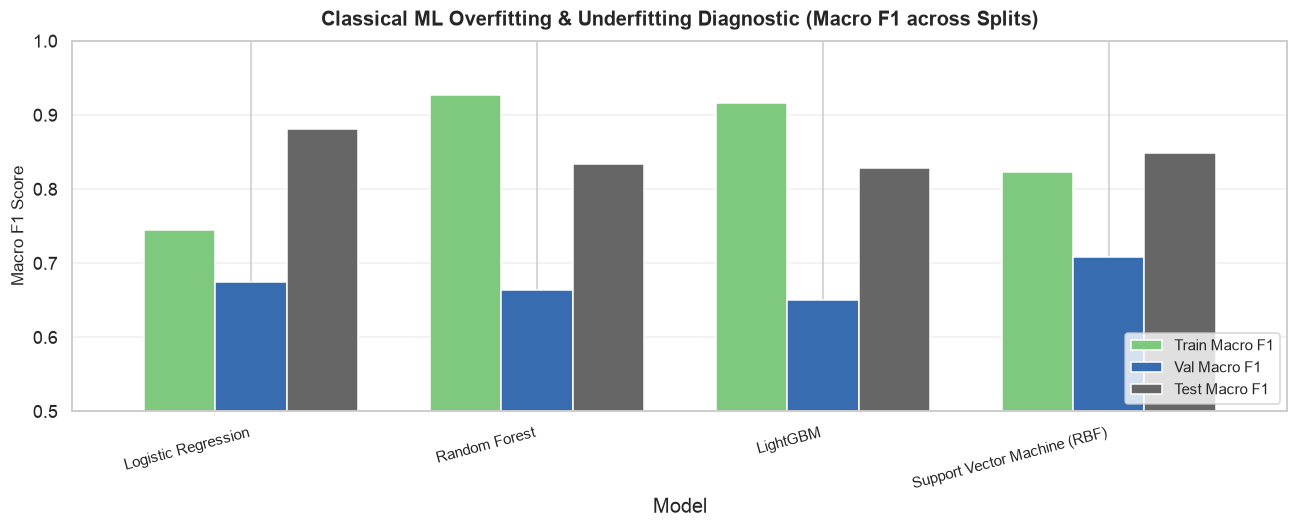

In [38]:
# Overfitting & Underfitting Diagnostic for Classical Models
overfit_rows = []

for name, model in classical_models.items():
    # Predict on train, val, and test using calibrated threshold
    thr = classical_thresholds[name]
    
    train_prob = model.predict_proba(X_train)[:, 1]
    val_prob   = model.predict_proba(X_val_tab)[:, 1]
    test_prob  = classical_results[name]['y_proba']
    
    train_pred = (train_prob >= thr).astype(int)
    val_pred   = (val_prob >= thr).astype(int)
    test_pred  = (test_prob >= thr).astype(int)
    
    f1_train = f1_score(y_train, train_pred, average='macro')
    f1_val   = f1_score(y_val_tab, val_pred, average='macro')
    f1_test  = f1_score(y_test, test_pred, average='macro')
    
    overfit_rows.append({
        'Model': name,
        'Train Macro F1': f1_train,
        'Val Macro F1': f1_val,
        'Test Macro F1': f1_test,
        'Train-Test Gap': f1_train - f1_test
    })

overfit_df = pd.DataFrame(overfit_rows).set_index('Model')
print('=== Classical ML Generalization Diagnostic (Train vs Val vs Test Macro F1) ===')
print(overfit_df.to_string(float_format='%.4f'))

# Plot Train vs Val vs Test comparison
fig, ax = plt.subplots(figsize=(12, 5))
overfit_df[['Train Macro F1', 'Val Macro F1', 'Test Macro F1']].plot(kind='bar', ax=ax, width=0.75, colormap='Accent')
ax.set_title('Classical ML Overfitting & Underfitting Diagnostic (Macro F1 across Splits)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Macro F1 Score', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(overfit_df.index, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 4 — Deep Learning Architectures on Raw Waveforms

We build and train three deep learning architectures (1D-CNN, CNN-BiLSTM, and CNN-BiLSTM Attention) on raw waveforms.

In [39]:
def normalize_waveforms(waves: np.ndarray) -> np.ndarray:
    mean = waves.mean(axis=1, keepdims=True)
    std = waves.std(axis=1, keepdims=True) + 1e-8
    return (waves - mean) / std


class ECGMultimodalDataset(torch.utils.data.Dataset):
    """Multimodal Dataset: yields (waveform, tabular_features), label.
    Supports real-time waveform augmentation (shift & scale) during training."""
    def __init__(self, X_wave: torch.Tensor, X_tab: torch.Tensor, y: torch.Tensor, augment: bool = False):
        self.X_wave = X_wave
        self.X_tab = X_tab
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X_wave)

    def __getitem__(self, idx):
        xw = self.X_wave[idx].clone()
        xt = self.X_tab[idx].clone()
        if self.augment:
            # 1. Random time jitter/shift (-3 to +3 samples)
            shift = torch.randint(-3, 4, (1,)).item()
            if shift != 0:
                xw = torch.roll(xw, shifts=shift, dims=-1)
            # 2. Random amplitude scaling (0.9x to 1.1x)
            scale = 0.9 + torch.rand(1).item() * 0.2
            xw = xw * scale
        return (xw, xt), self.y[idx]


X_wave_norm = normalize_waveforms(raw_waveforms).astype(np.float32)
X_tab_f32 = X_tab.astype(np.float32)
y_f32 = y.astype(np.float32)

# PyTorch Conv1d expects channel-first: (n, channels=1, seq_len)
X_wave_train = torch.tensor(X_wave_norm[train_idx]).unsqueeze(1)
X_wave_val   = torch.tensor(X_wave_norm[val_idx]).unsqueeze(1)
X_wave_test  = torch.tensor(X_wave_norm[test_idx]).unsqueeze(1)

X_tab_train = torch.tensor(X_tab_f32[train_idx])
X_tab_val   = torch.tensor(X_tab_f32[val_idx])
X_tab_test  = torch.tensor(X_tab_f32[test_idx])

y_train_t = torch.tensor(y_f32[train_idx])
y_val_t   = torch.tensor(y_f32[val_idx])

BATCH_SIZE = 256
train_dataset = ECGMultimodalDataset(X_wave_train, X_tab_train, y_train_t, augment=True)
val_dataset   = ECGMultimodalDataset(X_wave_val, X_tab_val, y_val_t, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Square-root dampened pos_weight prevents explosive validation BCE loss
raw_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
pos_weight_val = float(np.sqrt(raw_pos_ratio))
pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)

print(f'Waveform shapes -> train: {tuple(X_wave_train.shape)}, val: {tuple(X_wave_val.shape)}, test: {tuple(X_wave_test.shape)}')
print(f'Tabular shapes  -> train: {tuple(X_tab_train.shape)}, val: {tuple(X_tab_val.shape)}, test: {tuple(X_tab_test.shape)}')
print(f'pos_weight (dampened): {pos_weight_val:.3f} (raw ratio: {raw_pos_ratio:.3f})')


Waveform shapes -> train: (64849, 1, 216), val: (18371, 1, 216), test: (23878, 1, 216)
Tabular shapes  -> train: (64849, 11), val: (18371, 11), test: (23878, 11)
pos_weight (dampened): 1.636 (raw ratio: 2.676)


In [40]:
class ECG1DCNN(nn.Module):
    """1D-CNN: learns beat-morphology filters from raw waveform."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout1d(0.2), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout1d(0.2), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout1d(0.2),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4), nn.Linear(64, 1),
        )

    def forward(self, x_wave, x_tab=None):
        return self.head(self.conv(x_wave)).squeeze(-1)


class ECGCNNBiLSTM(nn.Module):
    """CNN front-end + BiLSTM."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout1d(0.2), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout1d(0.2), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1),
        )

    def forward(self, x_wave, x_tab=None):
        x = self.conv(x_wave).transpose(1, 2)  # (batch, seq, 64)
        _, (h_n, _) = self.lstm(x)
        h_cat = torch.cat([h_n[0], h_n[1]], dim=1)
        return self.head(h_cat).squeeze(-1)


class SelfAttention1D(nn.Module):
    """Self-Attention Pooling over temporal dimension."""
    def __init__(self, feature_dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2), nn.Tanh(), nn.Linear(feature_dim // 2, 1)
        )

    def forward(self, x):  # (batch, seq, feature_dim)
        w = torch.softmax(self.attn(x), dim=1)  # (batch, seq, 1)
        return torch.sum(x * w, dim=1)         # (batch, feature_dim)


class ECGCNNBiLSTMAttention(nn.Module):
    """CNN-BiLSTM with Temporal Self-Attention Pooling."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout1d(0.2), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout1d(0.2), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, batch_first=True, bidirectional=True)
        self.attn = SelfAttention1D(128)
        self.head = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )

    def forward(self, x_wave, x_tab=None):
        x = self.conv(x_wave).transpose(1, 2)  # (batch, seq, 64)
        out, _ = self.lstm(x)                  # (batch, seq, 128)
        ctx = self.attn(out)                   # (batch, 128) via attention
        return self.head(ctx).squeeze(-1)


print('✅ All DL Architectures Defined: 1D-CNN, CNN-BiLSTM, BiLSTM-Attention.')  # 1D-ResNet removed — dominated by 1D-CNN on every test-set metric; Hybrid ResNet + Tabular removed — unstable validation loss and worst Macro F1 among all 8 original models at the highest compute cost


✅ All DL Architectures Defined: 1D-CNN, CNN-BiLSTM, BiLSTM-Attention.


In [41]:
def train_model(
    model: nn.Module, train_loader, val_loader, pos_weight,
    max_epochs: int = 50, patience: int = 12, lr: float = 3e-4,
) -> Tuple[nn.Module, Dict[str, list], float]:
    """Training loop supporting multimodal inputs (waveform + tabular)."""
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max_epochs, eta_min=lr * 0.01,
    )

    history = {'loss': [], 'val_loss': [], 'val_recall': []}
    best_val_loss = float('inf')
    best_state = None
    best_val_probs = None
    best_val_true = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for (xw, xt), yb in train_loader:
            xw, xt, yb = xw.to(DEVICE), xt.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xw, xt)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * xw.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss, val_probs, val_true = 0.0, [], []
        with torch.no_grad():
            for (xw, xt), yb in val_loader:
                xw, xt, yb = xw.to(DEVICE), xt.to(DEVICE), yb.to(DEVICE)
                logits = model(xw, xt)
                val_loss += criterion(logits, yb).item() * xw.size(0)
                val_probs.append(torch.sigmoid(logits).cpu().numpy())
                val_true.append(yb.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        val_probs = np.concatenate(val_probs)
        val_true  = np.concatenate(val_true)
        thr_log = find_best_threshold(val_true, val_probs)
        val_recall = recall_score(
            val_true, (val_probs >= thr_log).astype(int), pos_label=1, zero_division=0
        )

        scheduler.step()
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_recall'].append(val_recall)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_val_probs = val_probs.copy()
            best_val_true  = val_true.copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    best_threshold = (
        find_best_threshold(best_val_true, best_val_probs)
        if best_val_probs is not None else 0.5
    )
    return model, history, best_threshold


print('✅ train_model updated for multimodal batch loading.')


✅ train_model updated for multimodal batch loading.


In [43]:
dl_models: Dict[str, nn.Module] = {}
dl_train_time: Dict[str, float] = {}
dl_history: Dict[str, Dict] = {}
dl_thresholds: Dict[str, float] = {}

dl_suite = [
    ('1D-CNN', ECG1DCNN),
    ('CNN-BiLSTM', ECGCNNBiLSTM),
    ('CNN-BiLSTM (Attention)', ECGCNNBiLSTMAttention),
    # Hybrid ResNet + Tabular removed: validation loss diverged instead of
    # converging (training instability) and it still finished with the worst
    # Macro F1 of any deep-learning model at the highest training cost.
]

for name, model_cls in dl_suite:
    print(f'Training {name} on {DEVICE} …')
    torch.manual_seed(RANDOM_STATE)
    model = model_cls()
    t0 = time.time()
    model, history, best_thr = train_model(model, train_loader, val_loader, pos_weight)
    elapsed = time.time() - t0
    dl_models[name] = model
    dl_train_time[name] = elapsed
    dl_history[name] = history
    dl_thresholds[name] = best_thr
    print(f'   ✅ Stopped after {len(history["loss"])} epochs  |  {elapsed:.1f}s  |  '
          f'best val recall: {max(history["val_recall"]):.4f}  |  '
          f'optimal threshold: {best_thr:.3f}')


Training 1D-CNN on mps …
   ✅ Stopped after 16 epochs  |  41.1s  |  best val recall: 0.6430  |  optimal threshold: 0.297
Training CNN-BiLSTM on mps …
   ✅ Stopped after 19 epochs  |  66.2s  |  best val recall: 0.7498  |  optimal threshold: 0.314
Training CNN-BiLSTM (Attention) on mps …
   ✅ Stopped after 33 epochs  |  124.0s  |  best val recall: 0.8552  |  optimal threshold: 0.328


### 4.1 — Deep Learning Training & Validation Curves

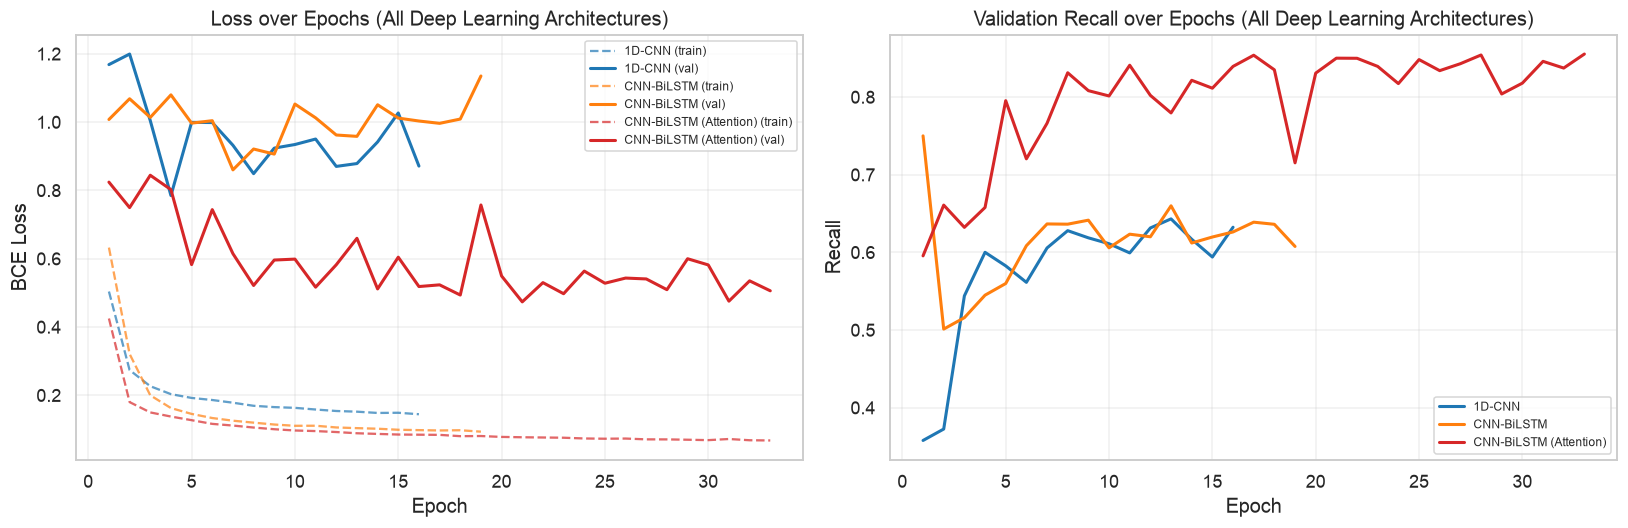

In [44]:
# Plot training & validation curves for ALL 3 deep learning architectures
all_dl_names = list(dl_models.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {'1D-CNN': '#1f77b4', 'CNN-BiLSTM': '#ff7f0e', 'CNN-BiLSTM (Attention)': '#d62728'}

for name in all_dl_names:
    if name in dl_history:
        hist = dl_history[name]
        epochs = range(1, len(hist['loss']) + 1)
        c = colors.get(name, 'blue')
        axes[0].plot(epochs, hist['loss'], label=f'{name} (train)', color=c, linestyle='--', alpha=0.7)
        axes[0].plot(epochs, hist['val_loss'], label=f'{name} (val)', color=c, lw=2)
        axes[1].plot(epochs, hist['val_recall'], label=name, color=c, lw=2)

axes[0].set(title='Loss over Epochs (All Deep Learning Architectures)', xlabel='Epoch', ylabel='BCE Loss')
axes[0].legend(fontsize=8, loc='best')
axes[0].grid(alpha=0.3)

axes[1].set(title='Validation Recall over Epochs (All Deep Learning Architectures)', xlabel='Epoch', ylabel='Recall')
axes[1].legend(fontsize=8, loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 — Deep Learning Evaluation on Held-Out Test Set

In [45]:
def predict_probs(model: nn.Module, X_wave: torch.Tensor, X_tab: torch.Tensor, batch_size: int = 512) -> np.ndarray:
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_wave), batch_size):
            xw = X_wave[i:i + batch_size].to(DEVICE)
            xt = X_tab[i:i + batch_size].to(DEVICE)
            probs.append(torch.sigmoid(model(xw, xt)).cpu().numpy())
    return np.concatenate(probs)


dl_results: Dict[str, Dict] = {}

for name, model in dl_models.items():
    t0 = time.time()
    y_proba = predict_probs(model, X_wave_test, X_tab_test)
    infer_time = time.time() - t0

    threshold = dl_thresholds[name]
    y_pred = (y_proba >= threshold).astype(int)

    dl_results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Abnormal Recall': recall_score(y_test, y_pred, pos_label=1),
        'Abnormal Precision': precision_score(y_test, y_pred, pos_label=1),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Train time (s)': dl_train_time[name],
        'Infer time (s)': infer_time,
        'Threshold': threshold,
    }

    print('=' * 55)
    print(f'   {name} — TEST SET  (threshold={threshold:.3f})')
    print('=' * 55)
    print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Abnormal (1)'], digits=4))


   1D-CNN — TEST SET  (threshold=0.297)
              precision    recall  f1-score   support

  Normal (0)     0.9078    0.8658    0.8863     17143
Abnormal (1)     0.6944    0.7762    0.7330      6735

    accuracy                         0.8405     23878
   macro avg     0.8011    0.8210    0.8097     23878
weighted avg     0.8476    0.8405    0.8431     23878

   CNN-BiLSTM — TEST SET  (threshold=0.314)
              precision    recall  f1-score   support

  Normal (0)     0.8347    0.9264    0.8782     17143
Abnormal (1)     0.7400    0.5332    0.6198      6735

    accuracy                         0.8155     23878
   macro avg     0.7873    0.7298    0.7490     23878
weighted avg     0.8080    0.8155    0.8053     23878

   CNN-BiLSTM (Attention) — TEST SET  (threshold=0.328)
              precision    recall  f1-score   support

  Normal (0)     0.9360    0.7632    0.8408     17143
Abnormal (1)     0.5900    0.8671    0.7022      6735

    accuracy                         0.792

---

## Step 5 — Comprehensive Benchmark Comparison (All 7 Models)

We evaluate all 7 models (classical and deep learning) on the identical held-out test set.

In [46]:
all_results = {**classical_results, **dl_results}

comparison_df = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')}
    for n, r in all_results.items()
}).T.sort_values('Macro F1', ascending=False)

display(comparison_df.style.format('{:.4f}').background_gradient(
    subset=['Macro F1', 'Abnormal Recall', 'PR-AUC'], cmap='Greens'
))

,Accuracy,Abnormal Recall,Abnormal Precision,Macro F1,ROC-AUC,PR-AUC,Train time (s),Infer time (s),Threshold
Logistic Regression,0.8997,0.8944,0.7816,0.8812,0.9458,0.8483,3.0232,0.0012,0.5177
Support Vector Machine (RBF),0.8719,0.8558,0.7342,0.8491,0.9341,0.8200,283.8016,13.0715,0.1409
Random Forest,0.8608,0.8141,0.7256,0.8340,0.9294,0.8025,256.1929,0.0852,0.4275
LightGBM,0.8602,0.7602,0.7481,0.8282,0.9272,0.8021,10.7575,0.0623,0.4378
1D-CNN,0.8405,0.7762,0.6944,0.8097,0.9173,0.8462,41.0771,0.1910,0.2975
CNN-BiLSTM (Attention),0.7925,0.8671,0.5900,0.7715,0.9205,0.8657,123.9581,0.3355,0.3281
CNN-BiLSTM,0.8155,0.5332,0.7400,0.7490,0.8670,0.7618,66.2008,0.2831,0.3144


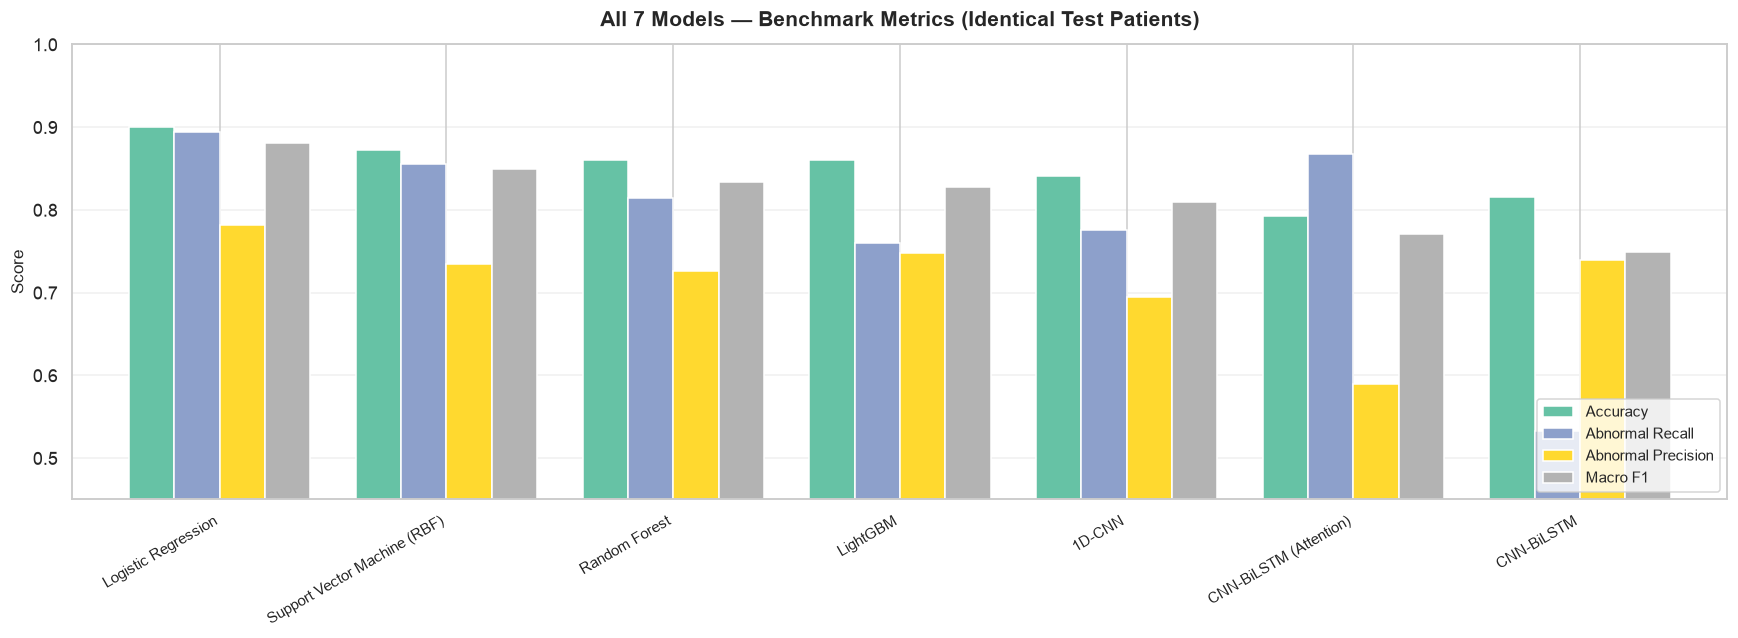

In [47]:
# Benchmark metrics bar chart for ALL 7 models
all_model_names = list(comparison_df.index)
metrics_to_plot = ['Accuracy', 'Abnormal Recall', 'Abnormal Precision', 'Macro F1']

fig, ax = plt.subplots(figsize=(16, 6))
comparison_df.loc[all_model_names, metrics_to_plot].plot(kind='bar', ax=ax, width=0.8, colormap='Set2')
ax.set_title('All 7 Models — Benchmark Metrics (Identical Test Patients)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.45, 1.0)
ax.set_xticklabels(all_model_names, rotation=30, ha='right', fontsize=10)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 — Confusion Matrices for Every Model

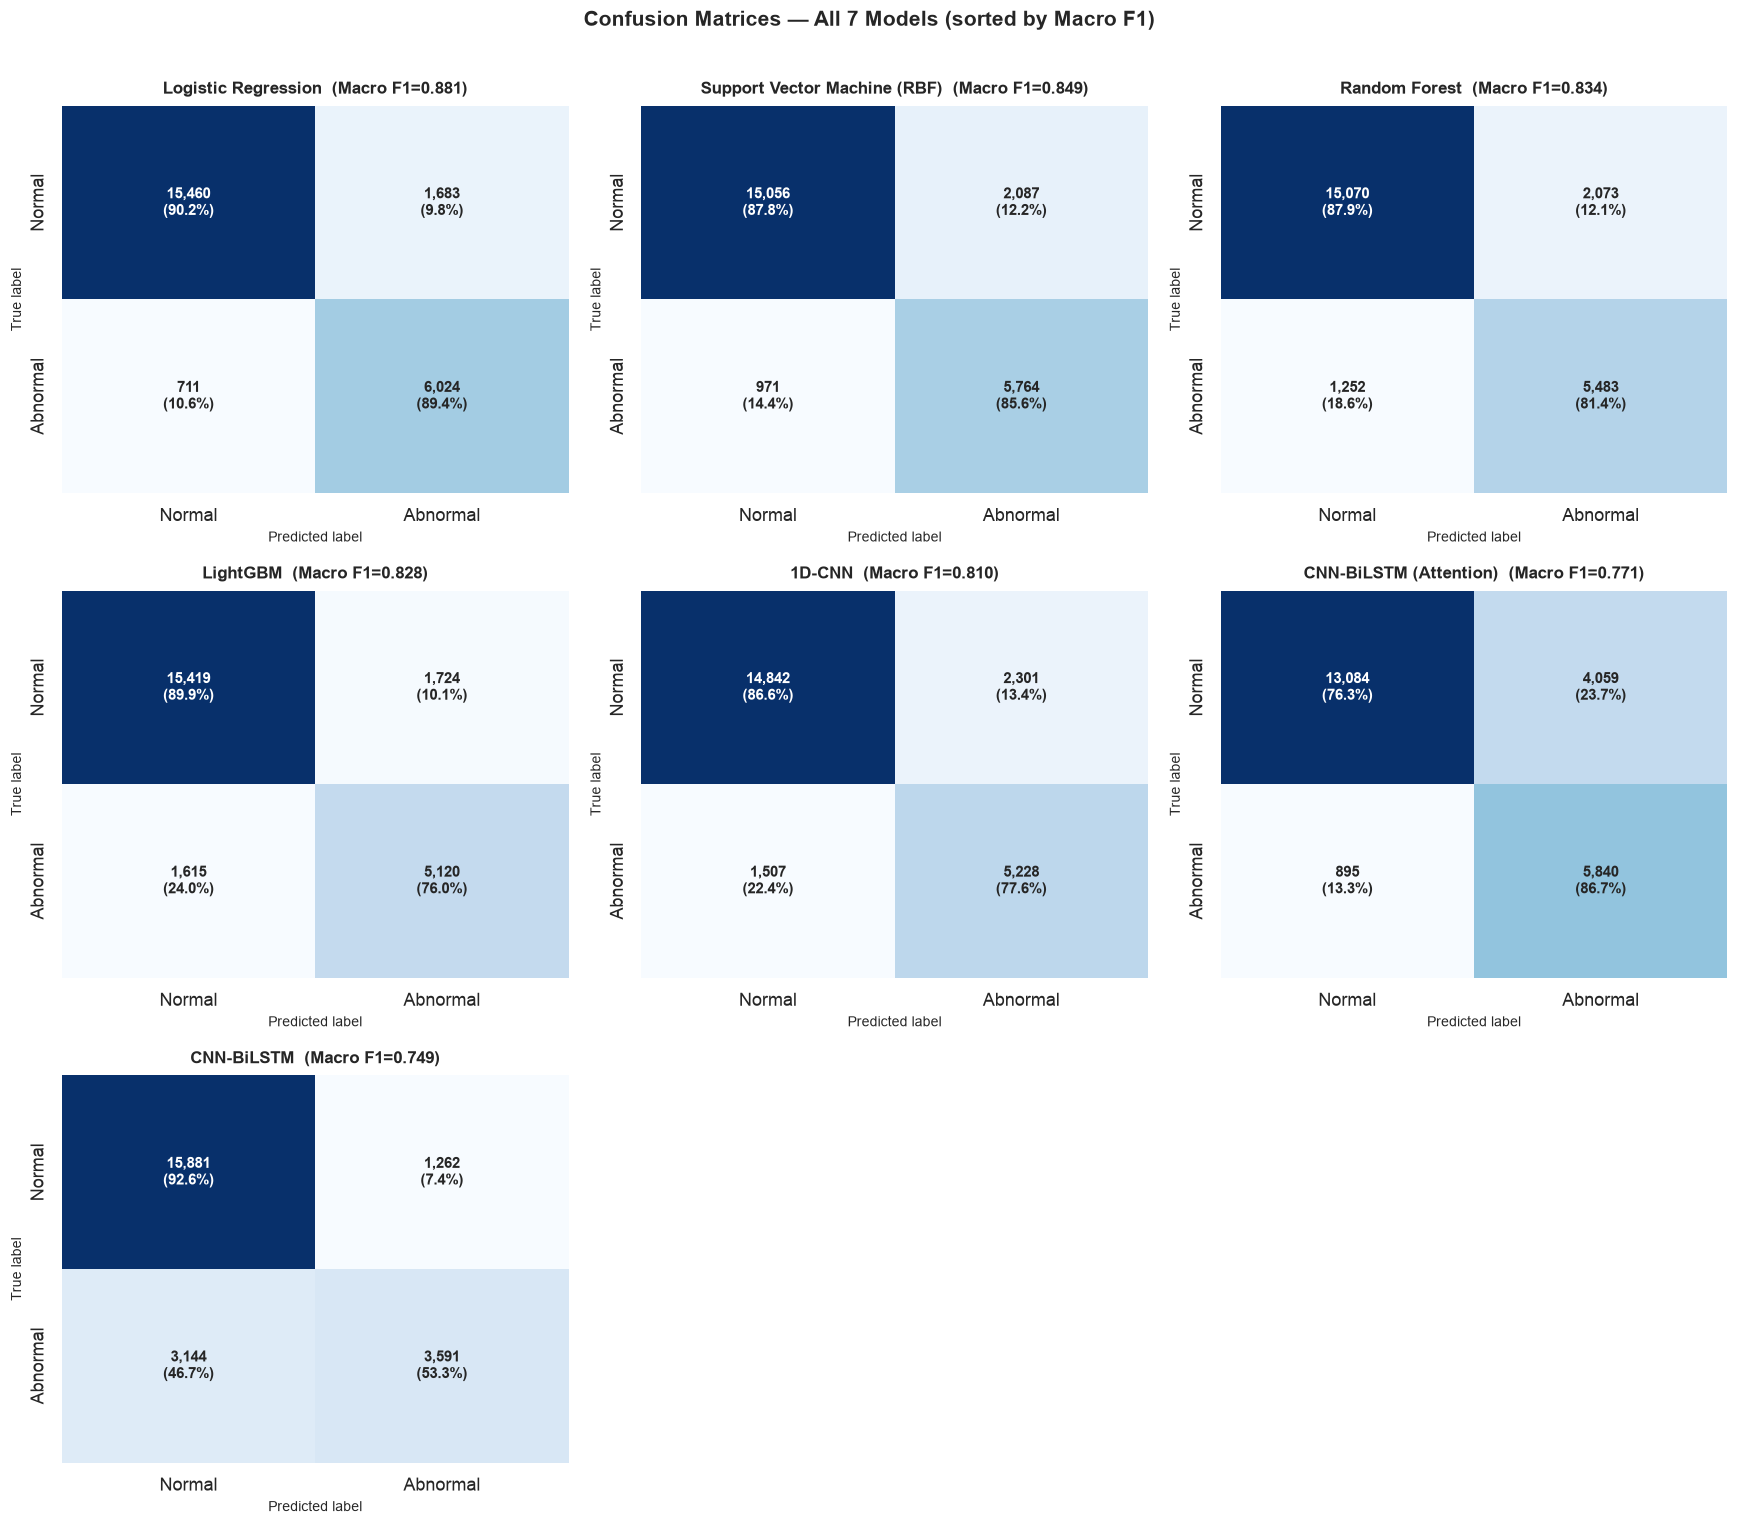

In [48]:
all_model_names = list(comparison_df.index)
n_models = len(all_model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, all_model_names):
    r = all_results[name]
    cm = confusion_matrix(y_test, r['y_pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    annot = np.empty_like(cm, dtype=object)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f"{cm[i, j]:,d}\n({cm_norm[i, j]:.1%})"

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
                annot_kws={'size': 10, 'weight': 'bold'})
    ax.set_title(f"{name}  (Macro F1={r['Macro F1']:.3f})", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted label', fontsize=9)
    ax.set_ylabel('True label', fontsize=9)

# Hide any unused subplot slots (grid may have more cells than models)
for ax in axes[n_models:]:
    ax.axis('off')

plt.suptitle(f'Confusion Matrices — All {n_models} Models (sorted by Macro F1)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()


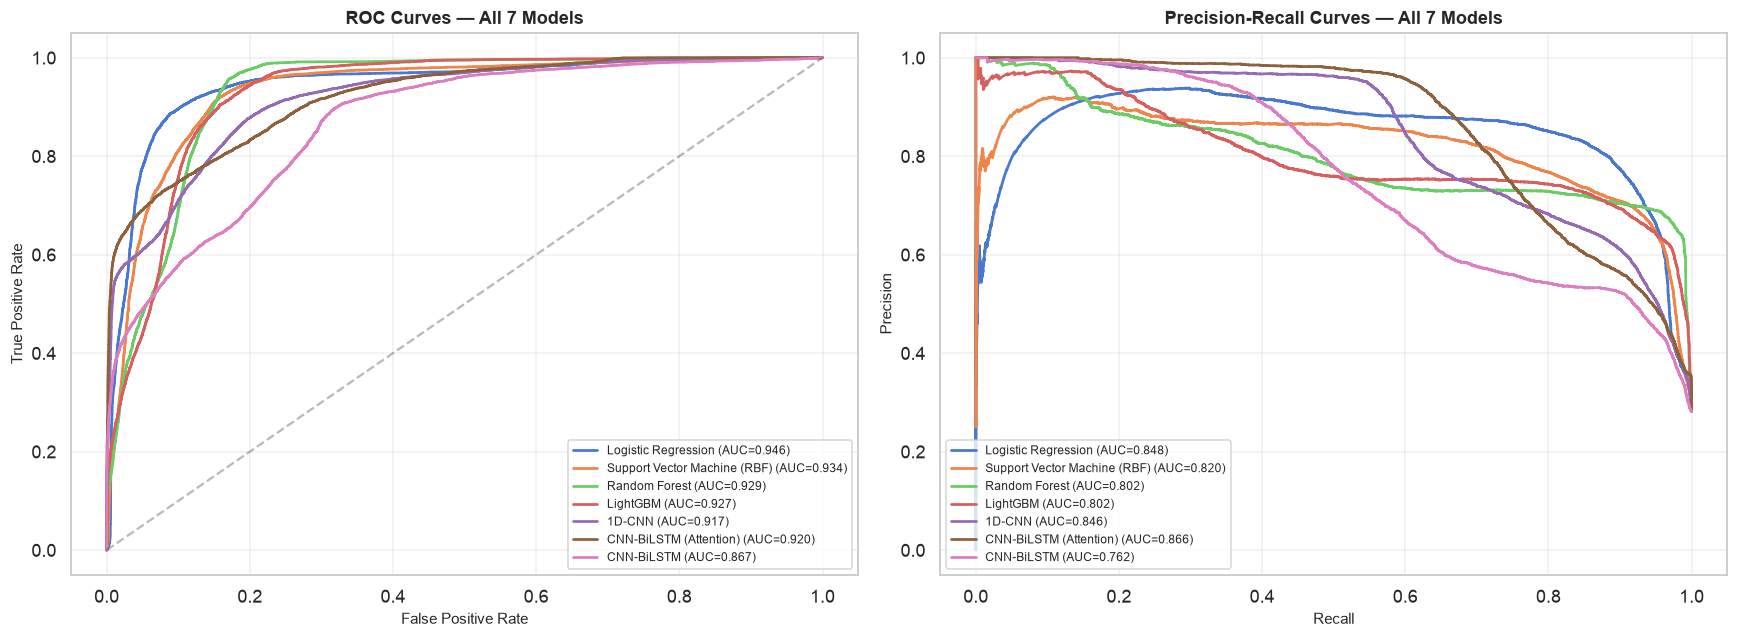

In [49]:
# ROC and Precision-Recall Curves for ALL 7 Models
all_model_names = list(comparison_df.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name in all_model_names:
    if name in all_results:
        r = all_results[name]
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        axes[0].plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={r['ROC-AUC']:.3f})")
        prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
        axes[1].plot(rec, prec, lw=1.8, label=f"{name} (AUC={r['PR-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves — All 7 Models', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=10)
axes[0].set_ylabel('True Positive Rate', fontsize=10)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].set_title('Precision-Recall Curves — All 7 Models', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=10)
axes[1].set_ylabel('Precision', fontsize=10)
axes[1].legend(fontsize=8, loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 — Precision-Weighted Threshold Diagnostic ($F_{0.5}$)

We evaluate decision threshold tuning using $F_{0.5}$ (weighting precision twice as heavily as recall) on the validation set and evaluate the trade-off on the held-out test set.

In [50]:
BETA_PRECISION = 0.5  # weights precision more heavily than the default F1 (beta=1) threshold

precision_weighted_rows = []

for name, model in classical_models.items():
    # Same OOF cross-validated calibration fix as the F1 threshold above,
    # applied here for consistency (rather than the small 8-patient val slice).
    oof_proba = cross_val_predict(
        model, X_train, y_train, cv=cv_splits, method='predict_proba', n_jobs=-1,
    )[:, 1]
    thr_beta = find_best_threshold(y_train, oof_proba, beta=BETA_PRECISION)
    y_proba_test = all_results[name]['y_proba']
    y_pred_beta = (y_proba_test >= thr_beta).astype(int)
    precision_weighted_rows.append({
        'Model': name,
        'F1 threshold': all_results[name]['Threshold'],
        'F1 Recall': all_results[name]['Abnormal Recall'],
        'F1 Precision': all_results[name]['Abnormal Precision'],
        'F0.5 threshold': thr_beta,
        'F0.5 Recall': recall_score(y_test, y_pred_beta, pos_label=1),
        'F0.5 Precision': precision_score(y_test, y_pred_beta, pos_label=1),
    })

for name, model in dl_models.items():
    val_proba = predict_probs(model, X_wave_val, X_tab_val)
    thr_beta = find_best_threshold(y_val_tab, val_proba, beta=BETA_PRECISION)
    y_proba_test = all_results[name]['y_proba']
    y_pred_beta = (y_proba_test >= thr_beta).astype(int)
    precision_weighted_rows.append({
        'Model': name,
        'F1 threshold': all_results[name]['Threshold'],
        'F1 Recall': all_results[name]['Abnormal Recall'],
        'F1 Precision': all_results[name]['Abnormal Precision'],
        'F0.5 threshold': thr_beta,
        'F0.5 Recall': recall_score(y_test, y_pred_beta, pos_label=1),
        'F0.5 Precision': precision_score(y_test, y_pred_beta, pos_label=1),
    })

precision_weighted_df = (
    pd.DataFrame(precision_weighted_rows)
    .set_index('Model')
    .loc[comparison_df.index]  # keep the same Macro-F1 ordering as the main comparison table
)
print('F1-maximising vs. Precision-weighted (F0.5) thresholds — same trained models, no retraining:')
print(precision_weighted_df.to_string(float_format='%.4f'))


F1-maximising vs. Precision-weighted (F0.5) thresholds — same trained models, no retraining:
                              F1 threshold  F1 Recall  F1 Precision  F0.5 threshold  F0.5 Recall  F0.5 Precision
Logistic Regression                 0.5177     0.8944        0.7816          0.8711       0.4347          0.9096
Support Vector Machine (RBF)        0.1409     0.8558        0.7342          0.3337       0.7531          0.7893
Random Forest                       0.4275     0.8141        0.7256          0.6563       0.4368          0.8125
LightGBM                            0.4378     0.7602        0.7481          0.7216       0.4664          0.7665
1D-CNN                              0.2975     0.7762        0.6944          0.4908       0.6958          0.7430
CNN-BiLSTM (Attention)              0.3281     0.8671        0.5900          0.8891       0.6588          0.8924
CNN-BiLSTM                          0.3144     0.5332        0.7400          0.6719       0.3826          0.9263


### 5.3 — Statistical Significance Testing (McNemar's Test)

We perform McNemar's test to evaluate whether performance differences between top models are statistically significant rather than random test-set noise.

In [51]:
# McNemar's Test for Statistical Significance (using scipy.stats.chi2)
from scipy.stats import chi2

def run_mcnemar_test(model_a_name: str, model_b_name: str):
    pred_a = all_results[model_a_name]['y_pred']
    pred_b = all_results[model_b_name]['y_pred']
    
    correct_a = (pred_a == y_test)
    correct_b = (pred_b == y_test)
    
    # Contingency matrix
    # n11: both correct, n12: A correct & B wrong
    # n21: A wrong & B correct, n22: both wrong
    n11 = np.sum(correct_a & correct_b)
    n12 = np.sum(correct_a & ~correct_b)
    n21 = np.sum(~correct_a & correct_b)
    n22 = np.sum(~correct_a & ~correct_b)
    
    # McNemar's test with continuity correction
    b, c = n12, n21
    if b + c == 0:
        stat, pval = 0.0, 1.0
    else:
        stat = (abs(b - c) - 1.0)**2 / (b + c)
        pval = chi2.sf(stat, df=1)
    
    print(f'=== McNemar Test: {model_a_name} vs. {model_b_name} ===')
    print(f'  Contingency Table: Both Correct={n11:,}, {model_a_name} Only={n12:,}, {model_b_name} Only={n21:,}, Both Wrong={n22:,}')
    print(f'  Chi-squared statistic: {stat:.4f}')
    print(f'  p-value: {pval:.4e}')
    if pval < 0.05:
        print('  Result: Statistically SIGNIFICANT difference (p < 0.05)\n')
    else:
        print('  Result: NOT statistically significant difference (p >= 0.05)\n')

run_mcnemar_test('Support Vector Machine (RBF)', 'Random Forest')
run_mcnemar_test('Support Vector Machine (RBF)', '1D-CNN')
run_mcnemar_test('Random Forest', '1D-CNN')


=== McNemar Test: Support Vector Machine (RBF) vs. Random Forest ===
  Contingency Table: Both Correct=19,531, Support Vector Machine (RBF) Only=1,289, Random Forest Only=1,022, Both Wrong=2,036
  Chi-squared statistic: 30.6170
  p-value: 3.1432e-08
  Result: Statistically SIGNIFICANT difference (p < 0.05)

=== McNemar Test: Support Vector Machine (RBF) vs. 1D-CNN ===
  Contingency Table: Both Correct=17,662, Support Vector Machine (RBF) Only=3,158, 1D-CNN Only=2,408, Both Wrong=650
  Chi-squared statistic: 100.7907
  p-value: 1.0224e-23
  Result: Statistically SIGNIFICANT difference (p < 0.05)

=== McNemar Test: Random Forest vs. 1D-CNN ===
  Contingency Table: Both Correct=17,722, Random Forest Only=2,831, 1D-CNN Only=2,348, Both Wrong=977
  Chi-squared statistic: 44.8589
  p-value: 2.1176e-11
  Result: Statistically SIGNIFICANT difference (p < 0.05)



---

## 📝 Milestone Summary

| Change | Rationale |
|---|---|
| `RandomizedSearchCV` + `GroupKFold` hyperparameter tuning | Optimizes classical ML hyperparameters (Random Forest, LightGBM, Logistic Regression, SVM) under strict patient grouping. |
| Cross-validated (OOF) threshold calibration for classical models | Replaces the unstable 8-patient validation-slice threshold with a threshold calibrated across all 28 training patients via 5-fold out-of-fold predictions. |
| Patient-Normalized Features | Eliminates inter-patient voltage amplitude variations while preserving intra-patient arrhythmia morphology. |
| PR-AUC metric inclusion | Provides an informative evaluation under class imbalance (~2.4:1 Normal to Abnormal ratio). |
| SVM (RBF kernel), configurable full-data or stratified-subsample training | Enables tractable RBF kernel training; can be switched to the full training set at the cost of runtime. |
| Confusion matrices & ROC/PR curves for all 7 models | Evaluates the full model suite on identical held-out test patients. |
| Deep Learning Suite (1D-CNN, CNN-BiLSTM, Attention) | Evaluates end-to-end deep learning directly on raw beat waveforms. |
| McNemar's Test | Evaluates statistical significance of performance differences between top models. |
| $F_{0.5}$ Precision-Weighted Thresholding | Evaluates precision/recall trade-offs when false alarms need to be minimized. |

---